# Chapter 30 — Improve Candidate Recall with Multi-Scale Proposals

This self-contained notebook compares the Chapter 29 baseline LoG detector with a multi-scale, multi-threshold proposal ensemble, retrains the distance regressor, and evaluates top-k recall.


In [1]:
!pip install -q zarr

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.spatial.distance import cdist
from skimage.feature import blob_log
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 64.1 MB/s eta 0:00:00


In [2]:
base = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
sample_id = "44b6_12dfb391"
zarr_path = base / "train" / f"{sample_id}.zarr"
geff_path = base / "train" / f"{sample_id}.geff"

if not base.exists():
    raise FileNotFoundError("Attach the Biohub competition data with Kaggle Add Input.")

image = zarr.open(zarr_path, mode="r")["0"]
geff = zarr.open(geff_path, mode="r")

nodes_df = pd.DataFrame({
    "node_id": geff["nodes/ids"][:],
    "t": geff["nodes/props/t/values"][:],
    "z": geff["nodes/props/z/values"][:],
    "y": geff["nodes/props/y/values"][:],
    "x": geff["nodes/props/x/values"][:],
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
display(nodes_df.head())


Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


In [3]:
def pairwise_distances_3d(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=float)
    return cdist(a, b)


def evaluate_candidate_coverage(candidate_df, gt_df, radius=6.0):
    if len(gt_df) == 0:
        return {"num_gt": 0, "num_pred": len(candidate_df), "gt_detected": 0,
                "gt_missed": 0, "gt_recall": np.nan, "pred_matched": 0,
                "precision_like": np.nan}

    if len(candidate_df) == 0:
        return {"num_gt": len(gt_df), "num_pred": 0, "gt_detected": 0,
                "gt_missed": len(gt_df), "gt_recall": 0.0, "pred_matched": 0,
                "precision_like": 0.0}

    gt_points = gt_df[["z", "y", "x"]].to_numpy(dtype=float)
    pred_points = candidate_df[["z", "y", "x"]].to_numpy(dtype=float)
    dist = pairwise_distances_3d(gt_points, pred_points)
    gt_min = dist.min(axis=1)
    pred_min = dist.min(axis=0)
    gt_detected = int((gt_min <= radius).sum())
    pred_matched = int((pred_min <= radius).sum())

    return {"num_gt": len(gt_df), "num_pred": len(candidate_df),
            "gt_detected": gt_detected, "gt_missed": len(gt_df)-gt_detected,
            "gt_recall": gt_detected/len(gt_df), "pred_matched": pred_matched,
            "precision_like": pred_matched/len(candidate_df)}


In [4]:
baseline_config = {
    "name": "baseline", "min_sigma": 2.5, "max_sigma": 3.5,
    "num_sigma": 3, "threshold": 0.15,
}

proposal_configs = [
    {"name": "small_sensitive", "min_sigma": 1.5, "max_sigma": 2.5, "num_sigma": 3, "threshold": 0.08},
    {"name": "medium_sensitive", "min_sigma": 2.5, "max_sigma": 3.5, "num_sigma": 3, "threshold": 0.10},
    {"name": "medium_strict", "min_sigma": 2.5, "max_sigma": 4.0, "num_sigma": 4, "threshold": 0.15},
    {"name": "large_sensitive", "min_sigma": 3.5, "max_sigma": 5.0, "num_sigma": 4, "threshold": 0.08},
]

nms_radius = 3.0
oracle_radius = 6.0
distance_clip = 20.0
train_timesteps = [0, 8, 20, 40]
heldout_timesteps = [60, 80]
top_k_values = [25, 50, 100, 200, 400]


In [5]:
def detect_log_for_config(frame_3d, config):
    rows = []
    for z in range(frame_3d.shape[0]):
        sl = frame_3d[z].astype(np.float32)
        mn, mx = float(sl.min()), float(sl.max())
        if mx <= mn:
            continue
        sl = (sl - mn) / (mx - mn)
        blobs = blob_log(sl, min_sigma=config["min_sigma"], max_sigma=config["max_sigma"],
                         num_sigma=config["num_sigma"], threshold=config["threshold"])
        for y, x, sigma in blobs:
            y = int(np.clip(round(y), 0, frame_3d.shape[1]-1))
            x = int(np.clip(round(x), 0, frame_3d.shape[2]-1))
            rows.append({"z": z, "y": y, "x": x, "sigma": float(sigma),
                         "nms_score": float(frame_3d[z,y,x]),
                         "proposal_source": config["name"]})
    return pd.DataFrame(rows, columns=["z","y","x","sigma","nms_score","proposal_source"])


def combine_proposals(frame_3d, configs):
    tables = [detect_log_for_config(frame_3d, c) for c in configs]
    tables = [t for t in tables if len(t)]
    if not tables:
        return pd.DataFrame(columns=["z","y","x","sigma","nms_score","proposal_count","proposal_sources"])
    combined = pd.concat(tables, ignore_index=True)
    return combined.groupby(["z","y","x"], as_index=False).agg(
        proposal_count=("proposal_source", "nunique"),
        proposal_sources=("proposal_source", lambda v: "|".join(sorted(set(v)))),
        sigma=("sigma", "mean"),
        nms_score=("nms_score", "max"),
    )


def greedy_3d_nms(candidate_df, nms_radius=3.0):
    if len(candidate_df) == 0:
        return candidate_df.copy()
    work = candidate_df.sort_values(["proposal_count","nms_score"], ascending=[False,False]).reset_index(drop=True)
    kept = []
    while len(work):
        row = work.iloc[0].copy(); kept.append(row)
        p = np.array([row.z,row.y,row.x], dtype=float)
        pts = work[["z","y","x"]].to_numpy(dtype=float)
        d = np.sqrt(((pts-p)**2).sum(axis=1))
        work = work[d > nms_radius].reset_index(drop=True)
    return pd.DataFrame(kept).reset_index(drop=True)


In [6]:
def extract_patch_3d(volume, z, y, x, rz=2, ryx=4):
    z0,z1=max(0,z-rz),min(volume.shape[0],z+rz+1)
    y0,y1=max(0,y-ryx),min(volume.shape[1],y+ryx+1)
    x0,x1=max(0,x-ryx),min(volume.shape[2],x+ryx+1)
    return volume[z0:z1,y0:y1,x0:x1], (z0,z1,y0,y1,x0,x1)


def compute_2d_features(frame, candidate_df, patch_radius=4):
    rows=[]
    for _,r in candidate_df.iterrows():
        z,y,x=int(r.z),int(r.y),int(r.x)
        y0,y1=max(0,y-patch_radius),min(frame.shape[1],y+patch_radius+1)
        x0,x1=max(0,x-patch_radius),min(frame.shape[2],x+patch_radius+1)
        patch=frame[z,y0:y1,x0:x1]
        if patch.size==0: continue
        center=float(frame[z,y,x]); mean=float(patch.mean()); mx=float(patch.max()); std=float(patch.std())
        py,px=np.unravel_index(np.argmax(patch),patch.shape); cy,cx=(patch.shape[0]-1)/2,(patch.shape[1]-1)/2
        yy,xx=np.indices(patch.shape); mass=patch.astype(float)
        if mass.sum()>0:
            com_y=(yy*mass).sum()/mass.sum(); com_x=(xx*mass).sum()/mass.sum()
            com_offset=float(np.hypot(com_y-cy,com_x-cx))
        else: com_offset=0.0
        rows.append({"z":z,"y":y,"x":x,"center_intensity":center,"patch_mean":mean,
                     "patch_max":mx,"patch_std":std,"local_contrast":mx-mean,
                     "center_to_patch_max_dist":float(np.hypot(py-cy,px-cx)),
                     "patch_com_offset":com_offset,
                     "is_near_border":int(z<=1 or z>=frame.shape[0]-2 or y<=patch_radius or y>=frame.shape[1]-patch_radius-1 or x<=patch_radius or x>=frame.shape[2]-patch_radius-1)})
    return pd.DataFrame(rows)


def compute_3d_features(frame, candidate_df, rz=2, ryx=4):
    rows=[]
    for _,r in candidate_df.iterrows():
        z,y,x=int(r.z),int(r.y),int(r.x)
        patch,b=extract_patch_3d(frame,z,y,x,rz,ryx); z0,z1,y0,y1,x0,x1=b
        if patch.size==0: continue
        lz,ly,lx=z-z0,y-y0,x-x0
        center=float(patch[lz,ly,lx]); mean=float(patch.mean()); std=float(patch.std()); mx=float(patch.max())
        zline=patch[:,ly,lx]
        neighbors=[]
        if lz-1>=0: neighbors.append(patch[lz-1])
        if lz+1<patch.shape[0]: neighbors.append(patch[lz+1])
        neighbor_mean=float(np.mean([s.mean() for s in neighbors])) if neighbors else mean
        peak_z,_,_=np.unravel_index(np.argmax(patch),patch.shape)
        zz,yy,xx=np.indices(patch.shape); mass=patch.astype(float)
        if mass.sum()>0:
            cz=(zz*mass).sum()/mass.sum(); cy=(yy*mass).sum()/mass.sum(); cx=(xx*mass).sum()/mass.sum()
            com3=float(np.sqrt((cz-lz)**2+(cy-ly)**2+(cx-lx)**2))
        else: com3=0.0
        rows.append({"z":z,"y":y,"x":x,"center_voxel":center,"vol_mean":mean,"vol_std":std,"vol_max":mx,
                     "z_line_mean":float(zline.mean()),"z_line_std":float(zline.std()),"z_line_max":float(zline.max()),
                     "center_over_vol_mean":center/(mean+1e-6),"center_minus_vol_mean":center-mean,
                     "center_slice_minus_neighbor_mean":float(patch[lz].mean()-neighbor_mean),
                     "slice_mean_std":float(np.std([s.mean() for s in patch])),"z_peak_offset":int(abs(peak_z-lz)),
                     "mass_center_offset_3d":com3,"peak_to_mean_ratio":mx/(mean+1e-6),
                     "bright_fraction":float((patch>mean).mean())})
    return pd.DataFrame(rows)


In [7]:
def build_feature_table(image, t, detector_type, nms_radius=3.0):
    frame=np.asarray(image[t])
    if detector_type=="baseline":
        raw=detect_log_for_config(frame,baseline_config)
        if len(raw):
            raw=raw.groupby(["z","y","x"],as_index=False).agg(
                proposal_count=("proposal_source","nunique"),
                proposal_sources=("proposal_source",lambda v:"|".join(sorted(set(v)))),
                sigma=("sigma","mean"), nms_score=("nms_score","max"))
    elif detector_type=="multiscale":
        raw=combine_proposals(frame,proposal_configs)
    else:
        raise ValueError("detector_type must be baseline or multiscale")

    nms=greedy_3d_nms(raw,nms_radius)
    if len(nms)==0: return pd.DataFrame(),raw,frame
    f2=compute_2d_features(frame,nms[["z","y","x"]].copy())
    f3=compute_3d_features(frame,nms[["z","y","x"]].copy())
    df=nms.merge(f2,on=["z","y","x"],how="left").merge(f3,on=["z","y","x"],how="left")
    df["t"]=t; df["detector_type"]=detector_type
    return df,raw,frame

feature_cols=["sigma","proposal_count","center_intensity","patch_mean","patch_max","patch_std","local_contrast",
              "center_to_patch_max_dist","patch_com_offset","is_near_border","center_voxel","vol_mean","vol_std","vol_max",
              "z_line_mean","z_line_std","z_line_max","center_over_vol_mean","center_minus_vol_mean",
              "center_slice_minus_neighbor_mean","slice_mean_std","z_peak_offset","mass_center_offset_3d",
              "peak_to_mean_ratio","bright_fraction"]


In [8]:
coverage_rows=[]
for t in train_timesteps+heldout_timesteps:
    gt=nodes_df[nodes_df.t==t].copy()
    for detector_type in ["baseline","multiscale"]:
        feat,raw,frame=build_feature_table(image,t,detector_type,nms_radius)
        raw_m=evaluate_candidate_coverage(raw,gt,oracle_radius)
        nms_m=evaluate_candidate_coverage(feat,gt,oracle_radius)
        coverage_rows.append({"t":t,"detector_type":detector_type,"raw_candidates":len(raw),"nms_candidates":len(feat),
                              "raw_gt_recall":raw_m["gt_recall"],"nms_gt_recall":nms_m["gt_recall"],
                              "nms_precision_like":nms_m["precision_like"]})
coverage_df=pd.DataFrame(coverage_rows)
display(coverage_df)


,t,detector_type,raw_candidates,nms_candidates,raw_gt_recall,nms_gt_recall,nms_precision_like
0,0,baseline,1541,670,0.800000,0.800000,0.017910
1,0,multiscale,7795,1768,1.000000,1.000000,0.017534
2,8,baseline,1478,661,0.727273,0.727273,0.018154
3,8,multiscale,7696,1823,1.000000,1.000000,0.017553
4,20,baseline,1653,695,1.000000,1.000000,0.020144
5,20,multiscale,7968,1859,1.000000,1.000000,0.016676
6,40,baseline,1596,688,0.666667,0.666667,0.015988
7,40,multiscale,8022,1941,1.000000,1.000000,0.018032
8,60,baseline,1844,807,0.888889,0.888889,0.016109
9,60,multiscale,9146,2221,1.000000,1.000000,0.015308


,detector_type,mean_raw_candidates,mean_nms_candidates,mean_raw_gt_recall,mean_nms_gt_recall,mean_nms_precision_like
0,baseline,1680.5,734.0,0.791582,0.791582,0.015850
1,multiscale,8444.5,2012.0,1.000000,1.000000,0.015268


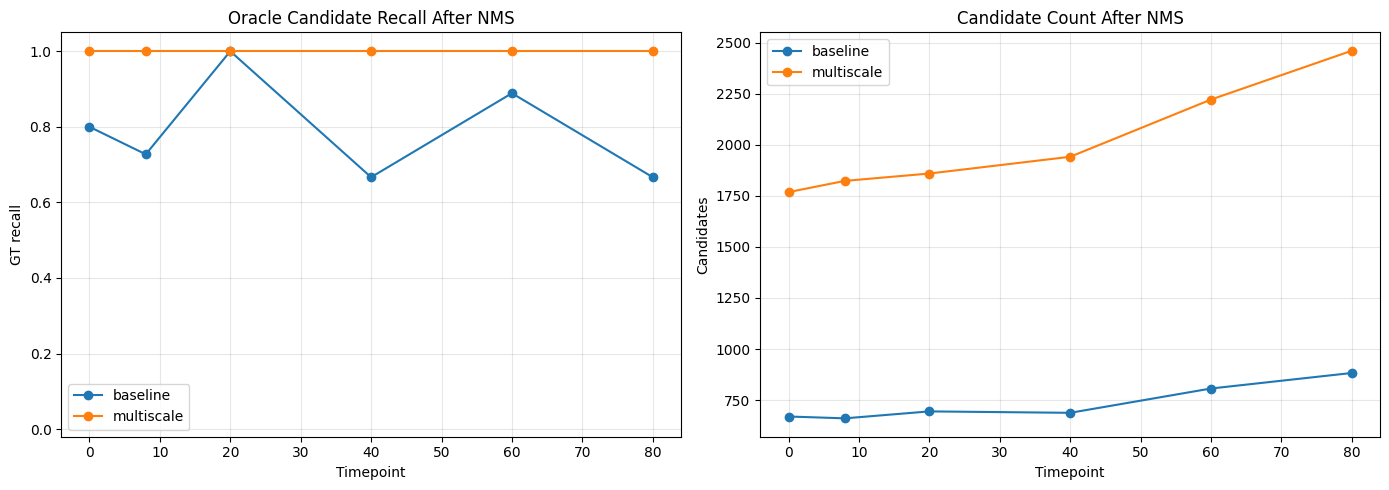

In [9]:
coverage_summary_df=(coverage_df.groupby("detector_type",as_index=False)
    .agg(mean_raw_candidates=("raw_candidates","mean"),mean_nms_candidates=("nms_candidates","mean"),
         mean_raw_gt_recall=("raw_gt_recall","mean"),mean_nms_gt_recall=("nms_gt_recall","mean"),
         mean_nms_precision_like=("nms_precision_like","mean")))
display(coverage_summary_df)

fig,axes=plt.subplots(1,2,figsize=(14,5))
for name,g in coverage_df.groupby("detector_type"):
    g=g.sort_values("t")
    axes[0].plot(g.t,g.nms_gt_recall,marker="o",label=name)
    axes[1].plot(g.t,g.nms_candidates,marker="o",label=name)
axes[0].set_title("Oracle Candidate Recall After NMS"); axes[0].set_xlabel("Timepoint"); axes[0].set_ylabel("GT recall"); axes[0].set_ylim(-.02,1.05); axes[0].legend(); axes[0].grid(True,alpha=.3)
axes[1].set_title("Candidate Count After NMS"); axes[1].set_xlabel("Timepoint"); axes[1].set_ylabel("Candidates"); axes[1].legend(); axes[1].grid(True,alpha=.3)
plt.tight_layout(); plt.show()


In [10]:
def build_training_table(detector_type):
    tables=[]
    for t in train_timesteps:
        feat,raw,frame=build_feature_table(image,t,detector_type,nms_radius)
        if len(feat)==0: continue
        gt=nodes_df[nodes_df.t==t]
        gt_pts=gt[["z","y","x"]].to_numpy(float); pred_pts=feat[["z","y","x"]].to_numpy(float)
        feat["nearest_gt_dist"]=pairwise_distances_3d(gt_pts,pred_pts).min(axis=0) if len(gt_pts) else np.inf
        feat["target_dist"]=feat.nearest_gt_dist.clip(0,distance_clip)
        tables.append(feat)
        print(f"{detector_type} | t={t}: raw={len(raw)}, nms={len(feat)}")
    return pd.concat(tables,ignore_index=True)

baseline_train_df=build_training_table("baseline")
multiscale_train_df=build_training_table("multiscale")

baseline_model=RandomForestRegressor(n_estimators=300,max_depth=10,min_samples_leaf=5,random_state=42,n_jobs=-1)
multiscale_model=RandomForestRegressor(n_estimators=300,max_depth=10,min_samples_leaf=5,random_state=42,n_jobs=-1)
baseline_model.fit(baseline_train_df[feature_cols].fillna(0),baseline_train_df.target_dist)
multiscale_model.fit(multiscale_train_df[feature_cols].fillna(0),multiscale_train_df.target_dist)
print("Baseline training rows:",len(baseline_train_df))
print("Multiscale training rows:",len(multiscale_train_df))


baseline | t=0: raw=1541, nms=670
baseline | t=8: raw=1478, nms=661
baseline | t=20: raw=1653, nms=695
baseline | t=40: raw=1596, nms=688
multiscale | t=0: raw=7795, nms=1768
multiscale | t=8: raw=7696, nms=1823
multiscale | t=20: raw=7968, nms=1859
multiscale | t=40: raw=8022, nms=1941
Baseline training rows: 2714
Multiscale training rows: 7391


In [11]:
def rank_candidates(image,t,detector_type,model):
    feat,raw,frame=build_feature_table(image,t,detector_type,nms_radius)
    if len(feat)==0: return feat,raw,frame
    ranked=feat.copy(); ranked["pred_dist"]=model.predict(ranked[feature_cols].fillna(0))
    ranked=ranked.sort_values("pred_dist").reset_index(drop=True)
    ranked["rank_position"]=np.arange(1,len(ranked)+1)
    ranked["node_id"]=[f"{detector_type}_t{t}_{i}" for i in range(len(ranked))]
    return ranked,raw,frame

ranking_rows=[]; ranked_tables={}
for t in heldout_timesteps:
    gt=nodes_df[nodes_df.t==t]
    for detector_type,model in [("baseline",baseline_model),("multiscale",multiscale_model)]:
        ranked,raw,frame=rank_candidates(image,t,detector_type,model)
        ranked_tables[(detector_type,t)]=ranked
        for top_k in top_k_values:
            metrics=evaluate_candidate_coverage(ranked.head(top_k),gt,oracle_radius)
            ranking_rows.append({"t":t,"detector_type":detector_type,"top_k":top_k,"full_pool":len(ranked),**metrics})
ranking_results_df=pd.DataFrame(ranking_rows)
display(ranking_results_df)


,t,detector_type,top_k,full_pool,num_gt,num_pred,gt_detected,gt_missed,gt_recall,pred_matched,precision_like
0,60,baseline,25,807,9,25,0,9,0.000000,0,0.0000
1,60,baseline,50,807,9,50,1,8,0.111111,1,0.0200
2,60,baseline,100,807,9,100,2,7,0.222222,2,0.0200
3,60,baseline,200,807,9,200,3,6,0.333333,3,0.0150
4,60,baseline,400,807,9,400,5,4,0.555556,5,0.0125
5,60,multiscale,25,2221,9,25,0,9,0.000000,0,0.0000
6,60,multiscale,50,2221,9,50,0,9,0.000000,0,0.0000
7,60,multiscale,100,2221,9,100,3,6,0.333333,3,0.0300
8,60,multiscale,200,2221,9,200,5,4,0.555556,5,0.0250
9,60,multiscale,400,2221,9,400,6,3,0.666667,10,0.0250


,detector_type,top_k,mean_gt_recall,mean_precision_like,mean_num_pred,mean_full_pool,mean_compression_ratio
0,baseline,25,0.000000,0.00000,25.0,845.0,33.80000
5,multiscale,25,0.000000,0.00000,25.0,2340.5,93.62000
1,baseline,50,0.222222,0.03000,50.0,845.0,16.90000
6,multiscale,50,0.000000,0.00000,50.0,2340.5,46.81000
2,baseline,100,0.277778,0.02500,100.0,845.0,8.45000
7,multiscale,100,0.250000,0.02000,100.0,2340.5,23.40500
8,multiscale,200,0.527778,0.02000,200.0,2340.5,11.70250
3,baseline,200,0.500000,0.02000,200.0,845.0,4.22500
4,baseline,400,0.611111,0.01375,400.0,845.0,2.11250
9,multiscale,400,0.583333,0.02000,400.0,2340.5,5.85125


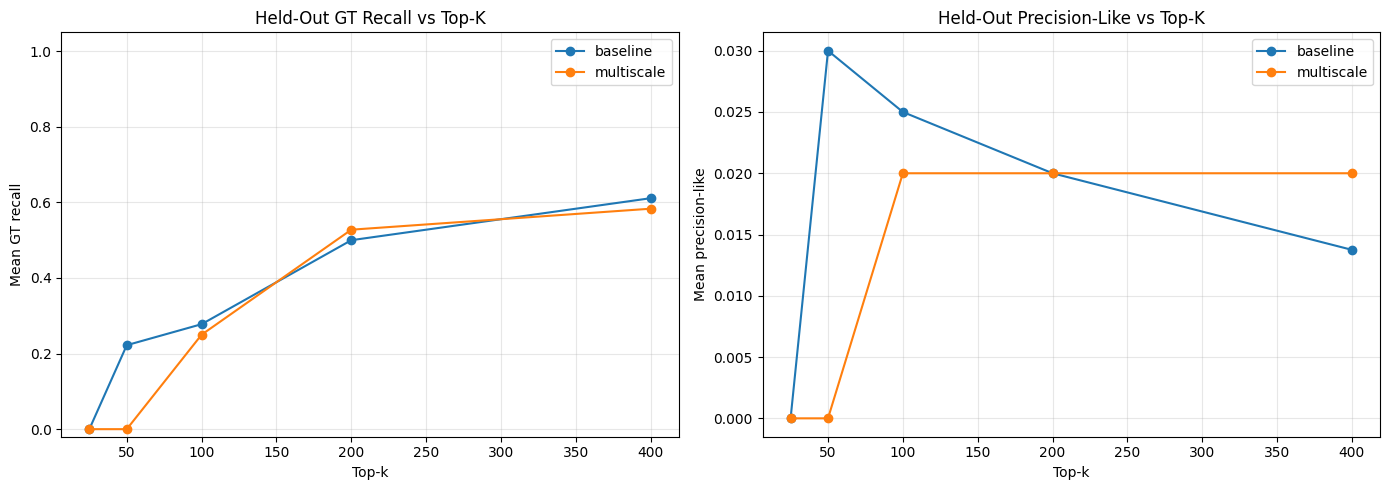

In [12]:
ranking_summary_df=(ranking_results_df.groupby(["detector_type","top_k"],as_index=False)
    .agg(mean_gt_recall=("gt_recall","mean"),mean_precision_like=("precision_like","mean"),
         mean_num_pred=("num_pred","mean"),mean_full_pool=("full_pool","mean")))
ranking_summary_df["mean_compression_ratio"]=ranking_summary_df.mean_full_pool/ranking_summary_df.mean_num_pred
display(ranking_summary_df.sort_values(["top_k","mean_gt_recall"],ascending=[True,False]))

fig,axes=plt.subplots(1,2,figsize=(14,5))
for name,g in ranking_summary_df.groupby("detector_type"):
    g=g.sort_values("top_k")
    axes[0].plot(g.top_k,g.mean_gt_recall,marker="o",label=name)
    axes[1].plot(g.top_k,g.mean_precision_like,marker="o",label=name)
axes[0].set_title("Held-Out GT Recall vs Top-K"); axes[0].set_xlabel("Top-k"); axes[0].set_ylabel("Mean GT recall"); axes[0].set_ylim(-.02,1.05); axes[0].legend(); axes[0].grid(True,alpha=.3)
axes[1].set_title("Held-Out Precision-Like vs Top-K"); axes[1].set_xlabel("Top-k"); axes[1].set_ylabel("Mean precision-like"); axes[1].legend(); axes[1].grid(True,alpha=.3)
plt.tight_layout(); plt.show()


,feature,importance
13,vol_max,0.076408
22,mass_center_offset_3d,0.076008
24,bright_fraction,0.066705
23,peak_to_mean_ratio,0.065605
12,vol_std,0.062588
19,center_slice_minus_neighbor_mean,0.062334
20,slice_mean_std,0.061874
15,z_line_std,0.060318
8,patch_com_offset,0.053034
17,center_over_vol_mean,0.051405


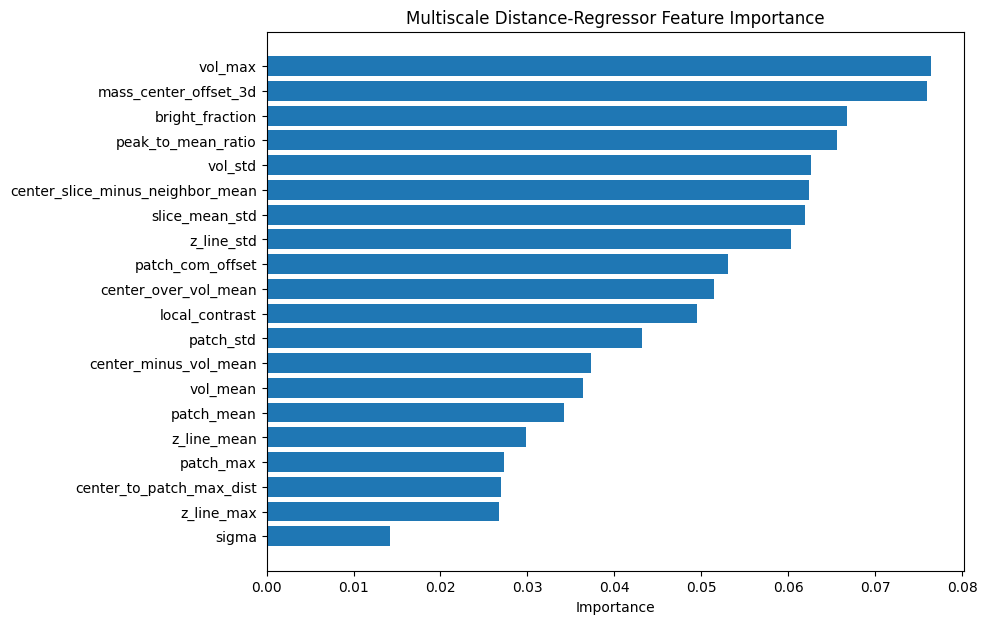

In [13]:
feature_importance_df=pd.DataFrame({"feature":feature_cols,"importance":multiscale_model.feature_importances_}).sort_values("importance",ascending=False)
display(feature_importance_df)
plt.figure(figsize=(9,7))
top=feature_importance_df.head(20).sort_values("importance")
plt.barh(top.feature,top.importance)
plt.title("Multiscale Distance-Regressor Feature Importance")
plt.xlabel("Importance")
plt.show()


In [14]:
selected_top_k=200
final_tables=[]
for t in range(0,21):
    ranked,raw,frame=rank_candidates(image,t,"multiscale",multiscale_model)
    selected=ranked.head(selected_top_k).copy(); final_tables.append(selected)
    print(f"t={t}: raw={len(raw)}, ranked={len(ranked)}, selected={len(selected)}")
chapter30_detections_df=pd.concat(final_tables,ignore_index=True)
display(chapter30_detections_df[["t","node_id","rank_position","z","y","x","proposal_count","pred_dist"]].head())


t=0: raw=7795, ranked=1768, selected=200
t=1: raw=7532, ranked=1773, selected=200
t=2: raw=7886, ranked=1799, selected=200
t=3: raw=7641, ranked=1798, selected=200
t=4: raw=7838, ranked=1851, selected=200
t=5: raw=7421, ranked=1754, selected=200
t=6: raw=7261, ranked=1735, selected=200
t=7: raw=7317, ranked=1729, selected=200
t=8: raw=7696, ranked=1823, selected=200
t=9: raw=7892, ranked=1854, selected=200
t=10: raw=8014, ranked=1862, selected=200
t=11: raw=8196, ranked=1941, selected=200
t=12: raw=7927, ranked=1881, selected=200
t=13: raw=7853, ranked=1879, selected=200
t=14: raw=8018, ranked=1859, selected=200
t=15: raw=8052, ranked=1890, selected=200
t=16: raw=8023, ranked=1871, selected=200
t=17: raw=8129, ranked=1945, selected=200
t=18: raw=8147, ranked=1925, selected=200
t=19: raw=8058, ranked=1900, selected=200
t=20: raw=7968, ranked=1859, selected=200


,t,node_id,rank_position,z,y,x,proposal_count,pred_dist
0,0,multiscale_t0_0,1,42,124,128,1,14.565597
1,0,multiscale_t0_1,2,24,123,85,3,14.809362
2,0,multiscale_t0_2,3,41,130,127,1,14.883600
3,0,multiscale_t0_3,4,41,130,135,1,14.899789
4,0,multiscale_t0_4,5,41,130,131,1,15.219577


In [15]:
coverage_output_path="/kaggle/working/chapter30_candidate_coverage.csv"
ranking_output_path="/kaggle/working/chapter30_ranking_results.csv"
summary_output_path="/kaggle/working/chapter30_ranking_summary.csv"
detections_output_path="/kaggle/working/chapter30_multiscale_detections.csv"
feature_importance_output_path="/kaggle/working/chapter30_feature_importance.csv"

coverage_df.to_csv(coverage_output_path,index=False)
ranking_results_df.to_csv(ranking_output_path,index=False)
ranking_summary_df.to_csv(summary_output_path,index=False)
chapter30_detections_df.to_csv(detections_output_path,index=False)
feature_importance_df.to_csv(feature_importance_output_path,index=False)

print("Saved:",coverage_output_path)
print("Saved:",ranking_output_path)
print("Saved:",summary_output_path)
print("Saved:",detections_output_path)
print("Saved:",feature_importance_output_path)


Saved: /kaggle/working/chapter30_candidate_coverage.csv
Saved: /kaggle/working/chapter30_ranking_results.csv
Saved: /kaggle/working/chapter30_ranking_summary.csv
Saved: /kaggle/working/chapter30_multiscale_detections.csv
Saved: /kaggle/working/chapter30_feature_importance.csv
